In [1]:
import sys
sys.path.append('C:\\Users\\nel_t\\Documents\\WORK\\PROJECTS\\Rankers')  # so that `src` is findable

In [13]:

info = {
    "Graph": {
        "type": "ER",
        "n": 1000,
        "p": 0.01
    },
    "OD": {
        "model": "BCM",
        "epsilon": 0.3,
        "mu": 0.1
    },
    "Ranker": {
        "rule": "Random"
    },
    "Simulation_details": {
        "n_steps": 2000,
        "convergence_window": 50,
        "convergence_delta": 1e-4
    },
    "post_history": 50,
    "k_posts": 5
}

In [14]:
from src.simulation import run_replicas

In [15]:
results = run_replicas(info, n_replicas=10)

Running 10 replicas...
  Replica 1/10
  Replica 2/10
  Replica 3/10
  Replica 4/10
  Replica 5/10
  Replica 6/10
  Replica 7/10
  Replica 8/10
  Replica 9/10
  Replica 10/10
Completed 10 replicas!
Convergence steps: min=153, max=169, mean=161


In [7]:
from src.analysis import save_results, load_results

save_results(results, r'C:\Users\nel_t\Documents\WORK\PROJECTS\Rankers\results\random_eps03')
# creates random_eps03.npz and random_eps03_config.json

results = load_results(r'C:\Users\nel_t\Documents\WORK\PROJECTS\Rankers\results\random_eps03')

In [8]:
import matplotlib.pyplot as plt

def plot_opinions_rep0(results):
    opinions = results['opinions_rep0']  # (n_steps, n_users)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(opinions, alpha=0.3, linewidth=0.5, color='steelblue')
    ax.set_xlabel('Step')
    ax.set_ylabel('Opinion')
    ax.set_ylim(0, 1)
    ax.set_title(f"Opinion trajectories - replica 0 (converged at step {len(opinions)})")
    ax.grid(True, alpha=0.3)
    
    return fig

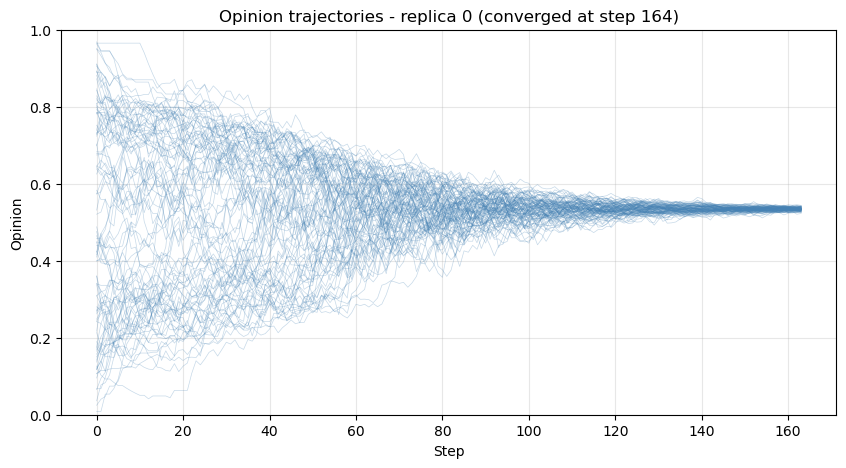

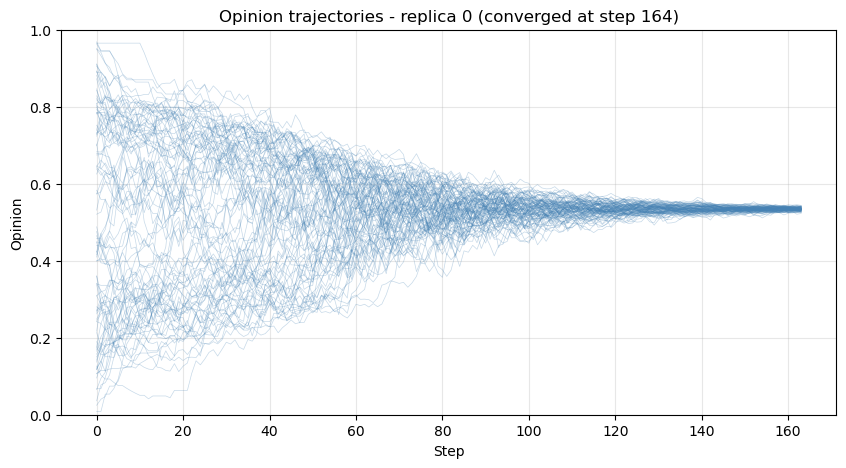

In [9]:
plot_opinions_rep0(results)

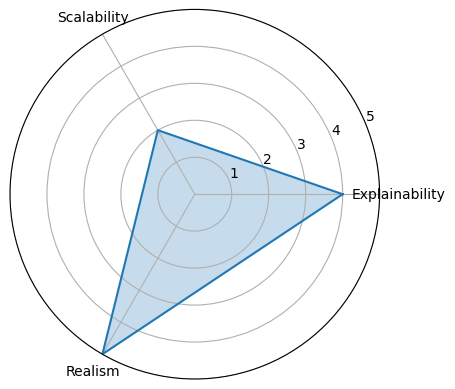

In [3]:
import numpy as np
import matplotlib.pyplot as plt

categories = ['Explainability', 'Scalability', 'Realism']
values = [4, 2, 5]

# Compute angles for each category (evenly spaced around the circle)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Close the polygon by repeating the first value/angle
values  = values + [values[0]]
angles  = angles + [angles[0]]

fig, ax = plt.subplots(subplot_kw=dict(polar=True))
ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 5)

plt.show()

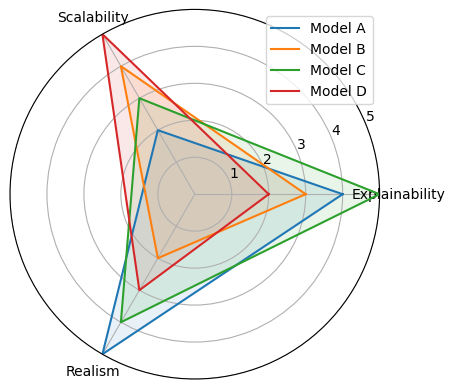

In [2]:
import numpy as np
import matplotlib.pyplot as plt

categories = ['Explainability', 'Scalability', 'Realism']
all_values = [
    [4, 2, 5],
    [3, 4, 2],
    [5, 3, 4],
    [2, 5, 3],
]
labels = ['Model A', 'Model B', 'Model C', 'Model D']

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles = angles + [angles[0]]

fig, ax = plt.subplots(subplot_kw=dict(polar=True))

for values, label in zip(all_values, labels):
    values = values + [values[0]]
    ax.plot(angles, values, label=label)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 5)
ax.legend()

plt.show()